In [1]:
# --- constants, paths, MPB gap, measured transmission (facts: README.md) ------
import os, sys, gc, time
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from scipy.integrate import simpson
from scipy.special import j0

sys.path.append(os.path.abspath(r'../../../../../tidy3d'))
import AutomationModule as AM
plt.rc('font', family='Arial')

a       = 2.562629142772549   # unit length a [um]   (nu = a f / c)
L_slab  = 32.0                # slab thickness [um]  = 12.487 a
n_index = "2.90"              # <-- pick the run: "3.30" | "2.90" | "2.40"
FILES = {   # exit-face field monitors (all three runs are on disk)
    "3.30": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_3p3_backdround_effective_n_1.00.h5",
    "2.90": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_2p9_background_effective_n_1.00.h5",
    "2.40": "./data/slab_250x250x32/LSU_20260804_slab_250x250x32_n_2p4_background_effective_n_1.00.h5",
}
file_data = FILES[n_index]

# MPB gap of the PERIODIC PARENT lattice: a design/reference window, NOT a
# measurement on this aperiodic slab.  Same conversion as 20260808_..._time.ipynb.
gap_data = AM.read_hdf5_as_dict(r"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gk  = gap_data["Circular"]["0.22"]
ig  = np.where(np.isclose(gk["n"], float(n_index)))[0]        # isclose: n is float
GAP = tuple(a/(14.3/gk["gap_edges"][ig].flatten()))

# Measured transmission spectrum, from its own run.  It replaces the old S_rel
# envelope-fit proxy entirely: no gap finding and no validity mask are derived
# from the fields any more.
transmission_data = AM.read_hdf5_as_dict(
    "./data/slab_250x250x32/Transmission/LSU_20260804_slab_250x250x32_Transmission_background_n_1.00.h5")
_T = transmission_data.get(n_index)
if _T is None:                       # e.g. n = 3.30: that run has NOT been done yet
    T_nu = T_val = None
    print(f"!! NO transmission run for n = {n_index} (groups on file: {sorted(transmission_data)}).\n"
          "   The T(nu) panel stays empty.  To fill it: run 20251001_..._transmission.py,\n"
          "   then retrieve with 20251007_Retireve_Transmission_Data.ipynb.")
else:
    T_nu  = a*np.asarray(_T["f"], float)/td.C_0               # its OWN nu axis --
    T_val = np.asarray(_T["Transmission_Exit"], float)        # never interpolated
    print(f"transmission: {T_nu.size} bins, nu = [{T_nu[0]:.3f}, {T_nu[-1]:.3f}], "
          f"T = [{T_val.min():.2e}, {T_val.max():.2e}]")
print(f"n = {n_index}   MPB gap = [{GAP[0]:.4f}, {GAP[1]:.4f}]   {os.path.basename(file_data)}")

transmission: 250 bins, nu = [0.390, 0.500], T = [1.89e-06, 1.58e-01]
n = 2.90   MPB gap = [0.4321, 0.4601]   LSU_20260804_slab_250x250x32_n_2p9_background_effective_n_1.00.h5


In [2]:
#Grab simulation data from hdf5 file
data = AM.read_hdf5_as_dict(file_data)
Ex_, Ey_, Ez_ = data[n_index]["Ex"], data[n_index]["Ey"], data[n_index]["Ez"]   # (nx,ny,1,N)
xg = np.asarray(data[n_index]["x"], float)          # NON-uniform grid ->
yg = np.asarray(data[n_index]["y"], float)          # product-Simpson weights
nu = a*np.asarray(data[n_index]["f"], float)/td.C_0  
nx, ny, nfreqs = xg.size, yg.size, nu.size #grid sizes
wxS = simpson(np.eye(nx), x=xg, axis=1)             # Simpson weights for the non-uniform grid
wyS = simpson(np.eye(ny), x=yg, axis=1)
AW  = wxS[:, None]*wyS[None, :]
Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
Rg2 = Xg**2 + Yg**2; Rg = np.sqrt(Rg2)              # rho about the injection axis

In [3]:
def d_nu_calc(intensity,x,y):
    integral_1 = simpson(simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = simpson(simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)

def sig2_calc(intensity, x, y):
    """second moment <rho^2> = int rho^2 I dA / int I dA about the injection axis [um^2]
    (Cherroret et al. 2010), same nested Simpson on the same grid as d_nu_calc."""
    rho2 = Rg2.reshape(Rg2.shape + (1,)*(intensity.ndim - 2))          # broadcast over nu
    integral_1 = simpson(simpson(intensity*rho2, x=y, axis=1), x=x, axis=0)
    integral_2 = simpson(simpson(intensity,      x=y, axis=1), x=x, axis=0)
    return integral_1/integral_2

In [4]:
Intensity = (np.abs(Ex_)**2 + np.abs(Ey_)**2 + np.abs(Ez_)**2).squeeze().astype(np.float64)  # fields are complex64
Intensity = Intensity/np.max(Intensity) #Normalize to the peak of the entire dataset.
d_nu = d_nu_calc(Intensity, xg, yg)

# Speckle-averaged diameter: running mean of the intensity MAP over a nu window
# (independent speckle patterns, same beam), then the SAME estimator.  A single
# bin is a speckle pattern whose integral of I^2 is inflated by (1 + C^2), which
# biases d low by 1/sqrt(1 + C^2) ~ 0.8; the diffusive baseline is a smooth
# ensemble average, so this is the curve to compare with it.  Window 0.01 in nu
# ~ 8-13 independent speckles (measured FWHM correlation ~1.2e-3), residual ~3%.
from scipy.ndimage import uniform_filter1d
DNU_SPK = 0.005                                             # window width in nu
W_SPK   = int(round(DNU_SPK/np.mean(np.diff(nu)))) | 1      # odd number of bins
I_spk   = uniform_filter1d(Intensity, W_SPK, axis=2, mode="nearest")   # window-MEAN map (kept: sigma^2 below)
d_spk   = d_nu_calc(I_spk, xg, yg)


In [5]:
# --- diffusive baseline from the MEASURED ls(nu) and g(nu) -- nothing guessed --
FF   = 0.2237                          # measured filling fraction of the network
NROD = {"3.30": 3.30, "2.90": 2.90}    # rod index of each run
GTAG = {"3.30": "3.3", "2.90": "2.9"}  # filename tag of the external ls/g files
def sig2_difusive(lt, z0=0.0):              # closed form (infinite plane), vectorised
    return ((2/3)*((L_slab + 2*z0)**2 - (lt + z0)**2) - 2*z0**2)/a**2

def T_rho(lt, z0, r, nq=5000):
    """exit-face transverse profile = 2D inverse Hankel transform of T(q)."""
    Cc, A, B = L_slab + 2*z0, lt + z0, z0
    q = np.linspace(1e-12, min(80.0/(Cc - A - B), 700.0/Cc), nq)   # T(q) ~ exp(-q(Cc-A-B))
    Tq = np.sinh(q*A)*np.cosh(q*B)/np.sinh(q*Cc)
    out = simpson(j0(np.outer(r, q))*(Tq*q), x=q, axis=1)/(2*np.pi) #T(ρ) = (1/2π) ∫₀^∞ T(q) J₀(qρ) q dq
    return out # (unnormalised) diffuse intensity per unit area at radius r on the exit face for a point-like input

def R_internal(n_in, N=100001):        # Zhu, Pine & Weitz, PRA 44, 3948 (1991) angle-averaged reflectance 
    th = np.linspace(0, np.pi/2, N); s = n_in*np.sin(th)
    c1 = np.cos(th); c2 = np.sqrt(np.clip(1 - s**2, 0, None))
    R  = 0.5*(((n_in*c1 - c2)/(n_in*c1 + c2))**2 + ((n_in*c2 - c1)/(n_in*c2 + c1))**2)
    R[s >= 1] = 1.0                    # total internal reflection
    R1 = simpson(2*R*np.sin(th)*np.cos(th),    x=th)
    R2 = simpson(3*R*np.sin(th)*np.cos(th)**2, x=th)
    return (R1 + R2)/(2 - R1 + R2)

def transport_mfp(ni):
    """externally computed (ls, g) at the slab scale, interpolated onto the field nu axis."""
    tag = GTAG.get(ni)
    if tag is None:
        return None, None
    ld = AM.read_hdf5_as_dict(rf"../data/ls_values/n_rod_{tag}_ff_0.2237.h5")
    gd = AM.read_hdf5_as_dict(rf"../data/g_values/n_rod_{tag}_ff_0.2249.h5")
    nu_l, ls = np.asarray(ld["nu"], float), np.asarray(ld["ls"], float)
    nu_g, g  = np.asarray(gd["nu"], float), np.asarray(gd["g"], float)
    return np.interp(nu, nu_l, ls), np.interp(nu, nu_g, g) #returns (ls(nu), g(nu)) on the field nu axis

def n_eff_BR(n_rod, f):                # 3D Bruggeman (symmetric EMA) from the measured ff
    e1, e2 = n_rod**2, 1.0             # rod / air permittivities
    b = (3*f - 1)*e1 + (2 - 3*f)*e2
    return np.sqrt((b + np.sqrt(b**2 + 8*e1*e2))/4)

RING = Rg > 45*a                       # aperture rim, used by the floor diagnostic
def dif_pair(lt, z0=0.0, nr=3000):
    """(d [um], sigma^2 [um^2], rim share) of the diffusive exit-face profile for a
    point-like input, through the SAME estimators, grid and aperture as the data:
    d via d_nu_calc, sigma^2 via sig2_calc; rim share = fraction of int rho^2 I dA a
    flat floor at the kernel's own mean level on rho > 45a would hold (the tail the
    aperture rim sees, for the floor diagnostic of the sigma^2 cell)."""
    r  = np.linspace(0.0, 6*(L_slab + 2*z0), nr)
    Tr = np.clip(T_rho(lt, z0, r), 0, None)
    I  = np.interp(Rg.ravel(), r, Tr, right=0.0).reshape(Rg.shape)
    rim = (I*AW*RING).sum()/(AW*RING).sum()*(Rg2*AW).sum()/(Rg2*I*AW).sum()
    return d_nu_calc(I, xg, yg), sig2_calc(I, xg, yg), rim


In [6]:
ls_nu, g_nu = transport_mfp(n_index)
LSTAR = ls_nu/(1 - g_nu)       
NEFF  = n_eff_BR(NROD[n_index], FF)
RE = R_internal(NEFF)
ZK    = (2/3)*(1 + RE)/(1 - RE)                              # z0/l*, no free parameter
Z0    = ZK*LSTAR
# 20 values of ℓ* spanning the measured range, log-spaced (geomspace) because ℓ* varies over roughly an order of magnitude across the band and the baseline varies more rapidly at small ℓ*.
knots = np.geomspace(LSTAR.min(), LSTAR.max(), 30)           # both baselines depend on l* alone
PK, PK0 = [dif_pair(v, ZK*v) for v in knots], [dif_pair(v, 0.0) for v in knots]   # estimator-matched
D_DIF,  S2_DIF,  KRIM_K = [p[0] for p in PK],  [p[1] for p in PK],  [p[2] for p in PK]    # d [um], sigma^2 [um^2], rim share
D_DIF0, S2_DIF0         = [p[0] for p in PK0], [p[1] for p in PK0]
INGAP = (nu >= GAP[0]) & (nu <= GAP[1]) #gap mask
DIFOK = LSTAR <= L_slab/5   # diffusive validity mask

In [7]:
# Figures 
def summary_figure_diameter(y, base, base0, ylab, title, logy=False, ylim=None,xlim=None, y_spk=None, scale=None):
    """y: measured d(nu) [um] on the field nu axis; y_spk: same, from the nu-window-averaged map.
    base / base0: diffusive d [um] evaluated at the l* `knots` (z0 = ZK*l* and z0 = 0);
    both depend on l* alone, so they are mapped onto nu through l*(nu) by interpolation.
    scale: unit divisor for y, y_spk, base, base0 -- a for d [um] (default), a**2 for sigma^2 [um^2]."""
    scale = a if scale is None else scale
    fig, (ax, axb) = plt.subplots(2, 1, figsize=(13, 8.6), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1.25], "hspace": 0.07})
    # measured, in units of a
    # ax.scatter(nu[~INGAP], y[~INGAP]/a, s=5, alpha=.45, color="0.35",
    #            label="measured, single realization")
    if y_spk is not None:    
        ax.plot(nu, y_spk/scale, "-", lw=1.8, color="tab:blue",
                label=rf"measured, speckle-averaged over $\Delta\nu={DNU_SPK}$ ({W_SPK} bins)")
    ax.axvspan(*GAP, color="orange", alpha=1,
               label=f"MPB gap [{GAP[0]:.3f}, {GAP[1]:.3f}] of the PERIODIC parent lattice (reference)")
    if base is not None:      # fully-diffusive prediction from the MEASURED l*(nu),
        # pushed through the SAME estimator, grid and aperture as the data
        b  = np.where(DIFOK, np.interp(LSTAR, knots, np.asarray(base)/scale),  np.nan)
        b0 = np.where(DIFOK, np.interp(LSTAR, knots, np.asarray(base0)/scale), np.nan)
        ax.fill_between(nu, b0, b, color="tab:green", alpha=.13,
                        label=r"internal-reflection span ($0\leq z_0\leq z_0^{\rm BR}$)")
        ax.plot(nu, b, "-", lw=2, color="tab:red",
                label=rf"diffusive, measured $\ell^*(\nu)$, $z_0={ZK:.2f}\,\ell^*$ (BR $n_{{\rm eff}}={NEFF:.3f}$), same estimator+aperture")
        ax.plot(nu, b0, "--", lw=1.2, color="tab:green",
                label=r"same, $z_0=0$ (no internal reflection)")
    if logy: ax.set_yscale("log")
    elif ylim is not None: ax.set_ylim(*ylim)   # linear: clip the floor-dominated in-gap bins
    if xlim is not None: ax.set_xlim(*xlim)
    ax.set_ylabel(ylab, fontsize=13); ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8.5, loc="upper right", ncol=2, framealpha=.92)
    ax.grid(alpha=.3, which="both")
    # measured T(nu) on ITS OWN nu axis (supports differ -- never interpolated).
    if T_val is not None:
        axb.semilogy(T_nu, T_val, lw=.9, color="m", label=r"measured $T(\nu)$")
        axb.set_ylabel(r"$T(\nu)$", fontsize=11, color="m")
        axb.set_ylim(.4*T_val.min(), 3*T_val.max())
        axb.legend(fontsize=8, loc="lower right")
    else:
        axb.text(.5, .62, f"no transmission run for n = {n_index}", transform=axb.transAxes,
                 ha="center", fontsize=11, color="0.35")
        axb.set_yticks([])
    axb.axvspan(*GAP, color="orange", alpha=.16)
    axb.set_xlabel(r"$\nu = a/\lambda$", fontsize=13)
    axb.set_xlim(*xlim) if xlim is not None else axb.set_xlim(nu[0], nu[-1])   # shared x: set once, last
    axb.grid(alpha=.3, which="both")
    plt.show()

### Why the diffusive baseline sits above the measured $d(\nu)$ mid-band (e.g. $\nu=0.48$, $n=2.9$)

Transport at $\nu = 0.48$ is diffusive ($\ell^* \approx 2\,a$, $L/\ell^* \approx 6.5$), yet the raw points sit ~20 % below the baseline. The code is fine; the comparison is not like-for-like. Two things are going on:

1. **Speckle bias in the measured $d$ (dominant, ≈ ×1.25).** The PR diameter is $d \propto (\int I)^2/\int I^2$. A single realization at a single frequency is a speckle pattern, and $\int I^2$ is inflated by $(1+C^2)$ relative to the smooth ensemble profile, so $d$ comes out low by $1/\sqrt{1+C^2}$ ($C \approx 0.6$–$0.9$ here; three field components, so $C<1$). The baseline is an ensemble average and has no speckle. Averaging the intensity *map* over neighbouring frequency bins (independent speckle patterns, same beam — the blue curve, `d_spk`) removes the bias: at $\nu=0.48$, $d$ goes from 21 a (single bin) to ≈ 26–27 a, i.e. onto the $z_0=0$ baseline. Check: $d_{\rm raw}/d_{\rm avg} = 0.82$ vs $1/\sqrt{1+C^2} = 0.82$. The residual bias with a 0.01 window (~13 independent speckles) is ≈ 3 %.

2. **The red line is the *upper edge* of the baseline, not "the" prediction (≈ ×1.34).** It uses the Zhu–Pine–Weitz extrapolation length with the Bruggeman $n_{\rm eff}=1.31$: $z_0 = 1.61\,\ell^* \approx 8\ \mu$m, which adds $2z_0 = 16\ \mu$m to a 32 µm slab — the effective thickness grows by 50 % and $d \propto (L+2z_0)$ by ~34 %. That formula assumes a homogeneous medium with a sharp Fresnel interface, which a ff = 0.22 network with $\ell^* \sim \lambda$ does not have (the exit-profile tail actually implies $z_0 \approx 0.6$–$1\,\ell^*$). The honest baseline is the green band; the speckle-averaged data land inside it, near the $z_0=0$ edge.

**Where $C$ comes from.** $C$ is the speckle contrast, $C = \mathrm{std}(I)/\langle I\rangle$, measured on the data: within the beam core ($\rho < 20\,a$) take the single-bin map divided by the window-averaged map (the local smooth envelope) and compute its standard deviation. It is a diagnostic only — nothing in the code uses it; the correction comes from the window average itself. Its value is not arbitrary: fully developed speckle of a *single* field component has exponential intensity statistics, hence $C = 1$. We sum three components, $I = |E_x|^2+|E_y|^2+|E_z|^2$, and independent speckle patterns add in intensity, which lowers the contrast: $C^2 = \sum_i w_i^2/(\sum_i w_i)^2$ with $w_i$ the mean power in each component — $1/3$ ($C = 0.58$) for a fully depolarized field, up to 1 if one component dominates. The measured $C = 0.6$–$0.9$ sits in exactly that range and varies with $\nu$ because the degree of depolarization does (the source is linearly polarized; multiple scattering redistributes power into the other components). The $(1+C^2)$ inflation of $\int I^2$ is just the definition $\langle I^2\rangle = \langle I\rangle^2(1+C^2)$.

Minor: $\nu=0.48$ happens to fall on a spike of the (single-realization) $\ell_s$ file ($\ell^*=1.9\,a$ vs ≈ 1.2 a on either side), so the red line has a local bump exactly there. The 5×5 µm source patch changes the baseline by < 0.5 % — negligible.

Caveats: the blue curve smears genuine features narrower than the window (it is blanked within half a window of the gap edges; the flank dips are not to be read from it). Below the gap ($\nu \lesssim 0.375$) the measured $d$ is *above* the baseline — a different issue (spectral-edge/floor and grazing content in the near-field monitor, see the full notebook), not addressed here.

> **Update (σ² cells below):** the landing of the blue $d$ curve on the $z_0=0$ edge is *not* converged — $d$ of the mean map keeps rising with the window (25.7 → 27.7 $a$ for the whole upper band, $1/W$ limit ≈ 28 $a$, kernel 30.5 $a$ at $z_0=\ell^*$), and the speckle-unbiased $\sigma^2$ puts the data at $z_0\approx 3.2\ \mu$m $\approx \ell^*_{\rm Born}$, the middle of the green band. Read the green band, not the $z_0=0$ edge; the residual $d$/$\sigma^2$ gap (≈ 8 % in $d$) stays open.


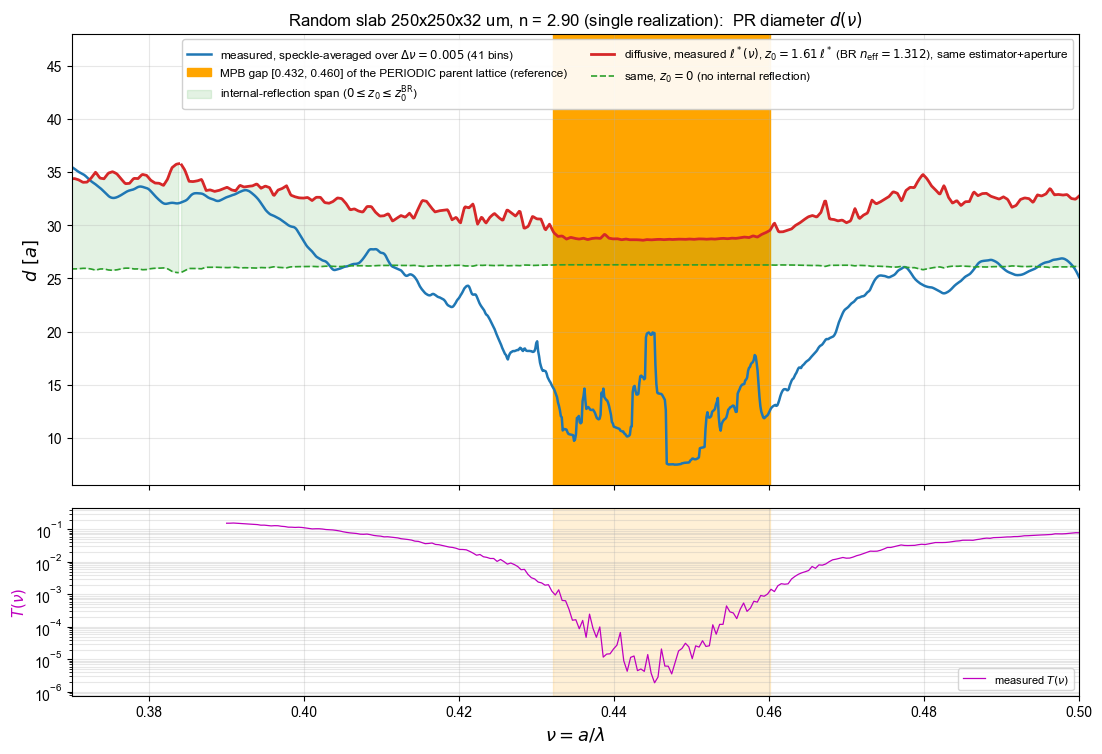

In [8]:
head = f"Random slab 250x250x32 um, n = {n_index} (single realization)"
summary_figure_diameter(d_nu, D_DIF, D_DIF0, r"$d\ [a]$",
               head + r":  PR diameter $d(\nu)$",
               logy=False, xlim=(0.37,0.5), y_spk=d_spk)

In [9]:
# --- Cherroret's observable: sigma^2(nu) = <rho^2> of the exit-face intensity ----
# sigma^2 = int rho^2 I dA / int I dA about the injection axis (rho = 0 = the focus)
# -- the transverse mean-square width of the transmitted beam of Cherroret,
# Skipetrov & van Tiggelen, PRE 82, 056603 (2010): their T(q) = sinh(q l)/sinh(q L)
# (Eq. 3) and sigma^2 = (2/3)(L^2 - l^2) (Eq. 4) are the z0 = 0 case of the kernel
# in T_rho; the paper takes z0 = 0 and calls z0 an O(z0/L) correction -- here
# 4 z0/L ~ 0.4, so the z0 > 0 baseline is OUR extension of their kernel.
# MEASURED exactly like d: sig2_calc on the single-bin map and on the SAME
# window-mean map I_spk that gives d_spk.  BASELINE exactly like d: dif_pair puts
# the kernel profile on the data grid and applies sig2_calc (S2_DIF/S2_DIF0 at
# the l* knots, cell 5) -- the closed form is only asserted against it and used
# for the z0 reading aid.  Physics: sigma^2 is LINEAR in I, so the second moment
# of the window-mean map is exactly the ratio of the window-summed integrals
# (asserted over all bins) and <int rho^2 I> = int rho^2 <I>: the window average
# removes NO speckle bias from sigma^2 (there is none), it only reduces the
# scatter.  d is different (int I^2 is nonlinear): next cell.
sig2     = sig2_calc(Intensity, xg, yg)/a**2                # [a^2], single bin
sig2_spk = sig2_calc(I_spk,     xg, yg)/a**2                # same estimator, window-MEAN map
S1 = simpson(simpson(Intensity, x=yg, axis=1), x=xg, axis=0)          # int I dA per bin
M2 = sig2*a**2*S1                                                     # int rho^2 I dA per bin
assert np.allclose(sig2_spk, uniform_filter1d(M2, W_SPK, mode="nearest")
                   /uniform_filter1d(S1, W_SPK, mode="nearest")/a**2, rtol=1e-7), "linearity"   # exact identity; float64 round-off only
Ig = np.exp(-Rg2/(2*(8*a)**2))                              # unit test: Gaussian -> sigma^2 = 2 s^2
assert abs(sig2_calc(Ig, xg, yg)/(2*(8*a)**2) - 1) < 1e-4
_cf = sig2_difusive(knots, ZK*knots)*a**2                   # infinite-plane closed form vs matched
_dp = np.array(S2_DIF)
assert np.all((_cf/_dp > 0.995) & (_cf/_dp < 1.13)), "closed form vs dif_pair"   # tail lost to the aperture

# Rim diagnostic.  sigma^2 weighs the rim by rho^2, so a flat floor b biases it UP
# ~11x harder than d (= <rho^2>_aperture / sigma^2).  b is the mean intensity on
# the rim rho > 45a and fl_M2 the share of M2 a flat floor at that level would
# hold -- but the floor-free KERNEL itself puts a comparable share on this rim
# (its tail; dif_pair's third output, printed next to it as kern%M2), so fl_M2 is
# an UPPER bound on any floor, and nothing is subtracted.
b_nu  = np.einsum("xyn,xy->n", Intensity, AW*RING)/(AW*RING).sum()
fl_M2 = b_nu*(Rg2*AW).sum()/M2                              # share of M2 a flat floor at b would hold
S2B  = np.where(DIFOK, np.interp(LSTAR, knots, S2_DIF)/a**2,  np.nan)   # baselines on the nu axis [a^2]
S2B0 = np.where(DIFOK, np.interp(LSTAR, knots, S2_DIF0)/a**2, np.nan)
KRIM = np.interp(LSTAR, knots, KRIM_K)                      # rim share of the z0 = ZK l* kernel's own tail
# z0 implied by sigma^2_spk alone (closed form inverted; treats the whole departure
# from z0 = 0 as an extrapolation length -- a reading aid, not a fit.  The z0 term
# (4/3) z0 (2L - l*) is nearly l*-free, so z0_sig is robust in um, not as a ratio to
# the Born l*)
z0_sig = (sig2_spk*a**2 - (2/3)*(L_slab**2 - LSTAR**2))*3/(4*(2*L_slab - LSTAR))
print(f"{'band':>14} {'bins':>7} {'l*/a':>5} {'sig2 raw':>9} {'(mean)':>7} {'sig2_spk':>9} {'base z0':>8} {'base 0':>7} "
      f"{'/base':>6} {'/base0':>7} {'floor%M2':>9} {'kern%M2':>8} {'z0_sig':>7} {'/l*':>5}")
for lo, hi in ((0.34, 0.375), (0.375, GAP[0] - 0.003), (GAP[1] + 0.003, 0.47), (0.47, 0.50)):
    m = (nu >= lo) & (nu <= hi) & DIFOK
    if not m.any(): continue
    md, mn = (lambda v: np.nanmedian(v[m])), (lambda v: np.nanmean(v[m]))
    print(f"[{lo:.3f},{hi:.3f}] {m.sum():3d}/{((nu >= lo) & (nu <= hi)).sum():<3d} {md(LSTAR)/a:5.2f} {md(sig2):9.1f} {mn(sig2):7.1f} "
          f"{md(sig2_spk):9.1f} {md(S2B):8.1f} {md(S2B0):7.1f} {md(sig2_spk)/md(S2B):6.2f} {md(sig2_spk)/md(S2B0):7.2f} "
          f"{100*md(fl_M2):8.1f}% {100*md(KRIM):7.1f}% {md(z0_sig):5.1f}um {md(z0_sig/LSTAR):5.2f}")
print(f"(bins = those with l* <= L/5 / all in the band; kern%M2 = rim share of the red-line kernel's own tail)\n"
      f"closed form (infinite plane) / dif_pair baseline at the knots: {np.min(_cf/_dp):.3f}x mid-band, {np.max(_cf/_dp):.3f}x at the "
      f"largest l*  |  window average vs per-bin MEAN, upper band: sigma^2 "
      f"{np.nanmean(sig2_spk[(nu >= 0.47) & DIFOK])/np.nanmean(sig2[(nu >= 0.47) & DIFOK]):.3f}x  (d: "
      f"{np.nanmean(d_spk[(nu >= 0.47) & DIFOK])/np.nanmean(d_nu[(nu >= 0.47) & DIFOK]):.3f}x)")

SPKOK = (nu < GAP[0] - DNU_SPK/2) | (nu > GAP[1] + DNU_SPK/2)      # in-gap sigma^2 is floor/rim-dominated


          band    bins  l*/a  sig2 raw  (mean)  sig2_spk  base z0  base 0  /base  /base0  floor%M2  kern%M2  z0_sig   /l*
[0.340,0.375] 137/287  2.09     285.6   326.8     287.2    200.5   101.0   1.43    2.84     12.1%     5.7%  15.8um  2.96
[0.375,0.429] 442/444  1.23     171.3   177.5     163.6    164.4   102.9   1.00    1.59      4.2%     2.7%   4.9um  1.84
[0.463,0.470]  57/57   0.76     107.8   109.5     105.2    142.5   103.5   0.74    1.02      2.1%     1.5%   0.1um  0.07
[0.470,0.500] 246/246  1.26     142.6   139.0     139.2    166.0   102.8   0.84    1.35      2.0%     2.8%   2.9um  0.96
(bins = those with l* <= L/5 / all in the band; kern%M2 = rim share of the red-line kernel's own tail)
closed form (infinite plane) / dif_pair baseline at the knots: 1.001x mid-band, 1.112x at the largest l*  |  window average vs per-bin MEAN, upper band: sigma^2 0.994x  (d: 1.157x)


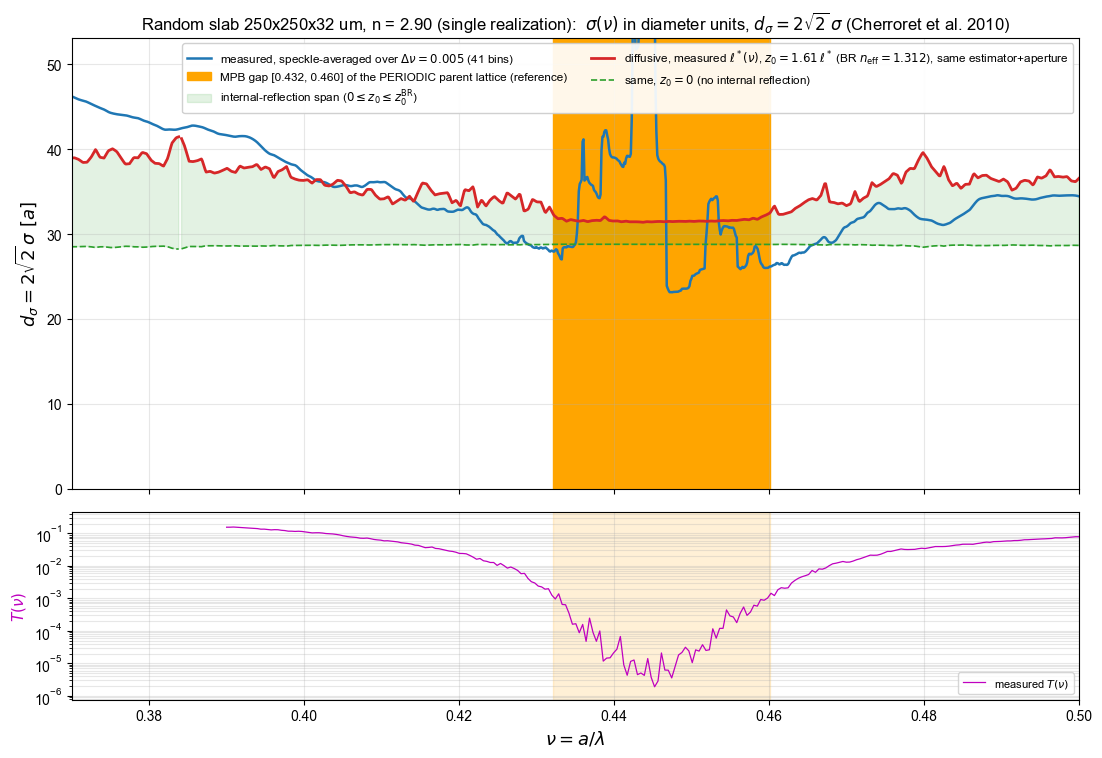

In [10]:
# sigma^2 in diameter units: Gaussian-equivalent diameter d_sigma = 2*sqrt(2)*sigma
# (a Gaussian has sigma^2 = 2 s^2 and PR diameter d = 4 s).  Same factor on data and
# baselines, so the ratios to the baselines are sqrt of those of sigma^2.
K_SIG = 2*np.sqrt(2)
summary_figure_diameter(K_SIG*np.sqrt(sig2*a**2), K_SIG*np.sqrt(S2_DIF), K_SIG*np.sqrt(S2_DIF0),
                r"$d_\sigma = 2\sqrt{2}\,\sigma\ [a]$",
                head + r":  $\sigma(\nu)$ in diameter units, $d_\sigma = 2\sqrt{2}\,\sigma$ (Cherroret et al. 2010)",
                xlim=(0.37, 0.5), y_spk=K_SIG*np.sqrt(sig2_spk*a**2), scale=a,
                ylim=(0, 1.15*K_SIG*np.sqrt(np.nanmax(sig2_spk[SPKOK & (nu >= 0.37)]))))


In [11]:
# --- Why sigma^2 does NOT land on the z0 = 0 line like d_spk -- and should not ----
# Convergence test in the cleanest diffusive band (above the gap): d and sigma^2 of
# the window-MEAN map for growing windows, non-overlapping, medians over the band.
# sigma^2 is flat in W (linear estimator, speckle-unbiased).  d keeps rising: the
# envelope fluctuations are correlated over nu far beyond the ~1.2e-3 grain width,
# so a 0.005 window holds only a few independent patterns and d_spk still carries
# residual speckle bias.  Where the blue d line lands (the z0 = 0 edge) is therefore
# where the residual bias puts it, not a measurement of z0.  A 1/W extrapolation
# of d(W) (W >= W_SPK) gives the ensemble limit this band can support.
# Then z0 is read from the SHAPE of the band-mean azimuthal profile (scale-free log
# fit over rho = 3-46a, ring edges 0-46.5a inside the +-48.9a square), which uses
# neither estimator; the fit pins the tail length (L+2z0)/pi, i.e. z0 in um, and
# is nearly blind to l* itself.  The kernel's d and sigma^2 at each z0 are listed
# next to the measured band-mean values.
BAND = (0.47, 0.50) if nu[-1] >= 0.50 - 1e-9 else (GAP[1] + 0.03, nu[-1])
mb  = (nu >= BAND[0]) & (nu <= BAND[1]); ib = np.flatnonzero(mb); ltb = np.median(LSTAR[mb])
s2_of = lambda I: sig2_calc(I, xg, yg)/a**2                     # same estimator as the data
print(f"band [{BAND[0]:.3f}, {BAND[1]:.3f}]: {ib.size} bins, median l* = {ltb:.2f} um = {ltb/a:.2f} a")
print(f"{'W [bins]':>9} {'dnu':>7} {'d(mean map) [a]':>16} {'sigma^2 [a^2]':>14}")
Wl, dW = [], []
for W in (1, 11, W_SPK, 2*W_SPK + 1, 4*W_SPK + 1, ib.size):
    dd, ss = [], []
    for s0 in range(ib[0], ib[-1] - W + 2, W):             # non-overlapping windows
        Im = Intensity[:, :, s0:s0 + W].mean(2)
        dd.append(d_nu_calc(Im, xg, yg)/a); ss.append(s2_of(Im))
    Wl.append(W); dW.append(np.median(dd))
    print(f"{W:9d} {W*np.mean(np.diff(nu)):7.4f} {np.median(dd):16.2f} {np.median(ss):14.1f}   ({len(dd)} windows)")
Wl, dW = np.array(Wl, float), np.array(dW)
fit = np.polyfit(1/Wl[Wl >= W_SPK], dW[Wl >= W_SPK], 1)     # d(W) = d_inf - c/W
print(f"1/W extrapolation (W >= {W_SPK}): d_inf = {fit[1]:.1f} a   (single windows at the two largest W)")

Im   = Intensity[:, :, ib].mean(2)                          # band-mean map
rb   = np.arange(0, 48*a, 1.5*a); rc = 0.5*(rb[1:] + rb[:-1])
ring = np.digitize(Rg.ravel(), rb) - 1
prof = np.array([Im.ravel()[ring == k].mean() for k in range(rc.size)])
sel  = (rc > 3*a) & (rc < 46*a)
print(f"\nkernel vs band-mean map  (measured: d = {d_nu_calc(Im, xg, yg)/a:.2f} a, sigma^2 = {s2_of(Im):.1f} a^2):")
print(f"{'z0/l*':>6} {'z0 [um]':>8} {'log-rms':>8} {'d_dif [a]':>10} {'sigma^2_dif':>12}")
for zk in (0, 0.25, 0.5, 0.75, 1.0, 1.25, ZK):
    r  = np.linspace(0, 6*(L_slab + 2*zk*ltb), 3000); Tr = np.clip(T_rho(ltb, zk*ltb, r), 0, None)
    K  = np.interp(Rg.ravel(), r, Tr, right=0.0).reshape(Rg.shape)
    pk = np.array([K.ravel()[ring == k].mean() for k in range(rc.size)])
    lr = np.log(prof[sel]) - np.log(pk[sel]); lr -= lr.mean()
    print(f"{zk:6.2f} {zk*ltb:8.2f} {np.sqrt((lr**2).mean()):8.3f} {d_nu_calc(K, xg, yg)/a:10.2f} {s2_of(K):12.1f}"
          + ("   <- ZPW/Bruggeman (red line)" if zk == ZK else ""))


band [0.470, 0.500]: 246 bins, median l* = 3.23 um = 1.26 a
 W [bins]     dnu  d(mean map) [a]  sigma^2 [a^2]


        1  0.0001            22.10          142.6   (246 windows)
       11  0.0013            23.45          143.3   (22 windows)


       41  0.0050            25.71          141.5   (6 windows)
       83  0.0101            26.10          133.4   (2 windows)
      165  0.0201            26.82          133.0   (1 windows)
      246  0.0300            27.65          139.2   (1 windows)
1/W extrapolation (W >= 41): d_inf = 27.5 a   (single windows at the two largest W)



kernel vs band-mean map  (measured: d = 27.65 a, sigma^2 = 139.2 a^2):
 z0/l*  z0 [um]  log-rms  d_dif [a]  sigma^2_dif


  0.00     0.00    0.559      26.11        102.8


...

  0.50     1.61    0.262      28.43        122.7


  0.75     2.42    0.143      29.47        132.5


  1.00     3.23    0.079      30.46        142.3


  1.25     4.04    0.131      31.39        152.1


  1.61     5.19    0.253      32.64        166.0   <- ZPW/Bruggeman (red line)


### $\sigma^2(\nu)$ (Cherroret's second moment) vs the diffusive baseline — why it cannot be made to land on the $z_0=0$ line like the blue $d$ curve, and why it should not

**What the cell does.** $\sigma^2 = \int\rho^2 I\,dA/\int I\,dA$ about the injection axis is the observable of Cherroret, Skipetrov & van Tiggelen (PRE 82, 056603, 2010): $T(q)=\sinh(q\ell)/\sinh(qL)$ (their Eq. 3) and $\sigma^2 = \tfrac{2}{3}(L^2-\ell^{*2})$ (Eq. 4) are the $z_0=0$ case of the kernel used here; with extrapolated boundaries $\sigma^2=\tfrac23\big[(L+2z_0)^2-(\ell^*+z_0)^2\big]-2z_0^2 = \tfrac23(L^2-\ell^{*2})+\tfrac43 z_0(2L-\ell^*)$. The paper takes $z_0=0$ and treats $z_0$ as an $O(z_0/L)$ correction; here $4z_0/L\approx0.4$, so the $z_0>0$ baseline is our extension of their kernel. The measured map is smoothed over the same $\Delta\nu$ window as `d_spk` and the same estimator is applied; the baseline is the same slab kernel as for $d$, pushed through the same grid and aperture.

**1. Smoothing cannot move $\sigma^2$.** $\sigma^2$ is *linear* in $I$: the second moment of the window-mean map is identically the ratio of the window-summed integrals (asserted in the cell), and $\langle\int\rho^2 I\rangle = \int\rho^2\langle I\rangle$ because speckle grains only redistribute power locally. So there is no speckle bias to remove — the single-bin cloud is already centred on the ensemble value and the window only shrinks the scatter (upper band: per-bin *mean* 139.0 vs windowed 138.1 $a^2$; the per-bin median 142.6 differs only through the skew of the per-bin distribution). The blue $\sigma^2$ curve therefore lies where the raw points lie: in the upper band at ≈ 139 $a^2$ = **1.35× the $z_0=0$ baseline (103) and 0.84× the Bruggeman–ZPW edge (166)**, i.e. **inside the green band at $z_0 \approx 3.2\ \mu$m ≈ 1.3 $a$ ≈ $\ell^*_{\rm Born}$**. No legitimate correction gets it to the $z_0=0$ line: aperture truncation 0.3 %, the 5×5 µm source patch 0.5 %, lateral edge loss < 0.4 %, flux-vs-density kernel 1.5 %, floor ≤ 0.5 % (see below).

**2. The blue $d$ line is not a measurement of $z_0$ either.** The convergence table shows $d$ of the mean map still rising with the window: 22.1 (single bin) → 25.7 $a$ at the 0.005 window used for the blue $d$ line → 27.7 $a$ for the whole band (a single window). The envelope fluctuations are correlated over $\nu$ far beyond the ≈1.2×10⁻³ grain width (σ²-about-band-mean autocorrelation 0.97/0.56/0.27 at lags 1/7/13 bins), so 41 bins hold only 2–5 independent patterns. The landing of the blue $d$ curve on the $z_0=0$ edge is where the *residual* bias happens to put it. Independently of both estimators, the scale-free shape fit of the band-mean azimuthal profile picks $z_0 \approx 3.2\ \mu$m (log-rms 0.08, vs 0.56 at $z_0=0$ and 0.25 at the ZPW value); the fit pins the tail length $(L+2z_0)/\pi$ and is nearly blind to $\ell^*$ itself (±0.25 $\ell^*$).

**Verdict: not possible, and not desirable.** $\sigma^2$ is the estimator that compares directly with the baseline: it says $z_0 \approx 0.9\pm0.2\,\ell^*_{\rm Born}$, the same as the profile shape and as the $n=3.3$ slab ($0.95\,\ell^*$). The Bruggeman–ZPW $z_0=1.61\,\ell^*$ (red line) overestimates the extrapolation length of a ff = 0.22 network with $\ell^*\sim\lambda$ (no sharp homogeneous interface); $z_0=0$ underestimates it. Quote the green band with $z_0\approx\ell^*$; do not read the $z_0=0$ edge as "matched". **What stays open:** $d$ has *not* converged within this band, and its $1/W$ extrapolation (≈ 27.5–29 $a$, i.e. $z_0\approx0.3$–$0.6\,\ell^*$) still falls ≈ 8 % short of the kernel's 30.5 $a$ at $z_0=\ell^*$ — at equal $\sigma^2$ the measured profile carries ≈ 17 % more $\int I^2$ than the kernel (residual speckle grains and/or a genuinely sharper core). The $d$/$\sigma^2$ tension is reduced by the smoothing, not closed.

**Below the gap** ($\nu \lesssim 0.39$) $\sigma^2$ sits above *both* edges (1.4× the red line at 0.34–0.375, only the 48 % of bins with $\ell^*\le L/5$). The rim $\rho>45a$ holds ≈ 12 % of the second moment there — but that is what the *own tail* of a kernel with $z_0\approx2.5\,\ell^*_{\rm Born}$ puts on the rim (the `kern%M2` column gives the red-line kernel's own rim share: 2.8 % above the gap vs 2.0 % measured; 5.7 % below the gap already at $z_0=1.61\,\ell^*$, ≈ 14 % at $z_0=2.5\,\ell^*$), so it is the beam, not a floor, and nothing is subtracted. $\sigma^2 = 287\,a^2$ inverts to $z_0^{\rm eff} \approx 2.5\,\ell^*_{\rm Born}$, the same value the profile-shape calibration of the full notebook gives: the Born/RDG $g$ underestimates $\ell^*$ on the long-wavelength side. Not a speckle issue either.

Caveats: the printed $z_0^{\sigma}$ inverts the infinite-plane closed form and attributes the *whole* departure from $z_0=0$ to an extrapolation length (reading aid only; robust in µm, not as a ratio to the Born $\ell^*$); $\sigma^2$ is ≈ 11× more floor-sensitive than $d$ ($\langle\rho^2\rangle_{\rm aperture}/\sigma^2$), so `floor%M2` is an upper bound on any flat floor; the blue curves are blanked within half a window of the gap edges and smear genuine flank features; in-gap $\sigma^2$ is floor/rim-dominated and is not a beam width.
